## Analytic Gaussian Bond Information ##

This notebook will generate the plot in Figure $5.2$ of the report; this is the figure analysing the values of the Bond Information for the 4-element graphs $Path_4$ and $C_4$ in the Gaussian case, for which the Tsallis-Alpha has an analytic expression and we can calculate the Bond Information analytically.

In [1]:
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from Modules.bond_finders import *
from Modules.gaussian_bond_information import *
from Modules.moebius_machinery import *

In [2]:
# Calculating bond informations for path
P_4 = nx.path_graph(4)
bond_facts_path, nonbond_facts_path = factorised_bi(P_4, walk_bond_finder, 0.8)

# Calculating bond informations for cycle
C_4 = nx.cycle_graph(4)
bond_facts_cycle, nonbond_facts_cycle = factorised_bi(C_4, walk_bond_finder, 0.8)

In [3]:
print(f"The Bond Information for the fully dependent joint with Path_4 is: {list(bond_facts_path.values())[-1]}")

The Bond Information for the fully dependent joint with Path_4 is: 0.0012350903462494678


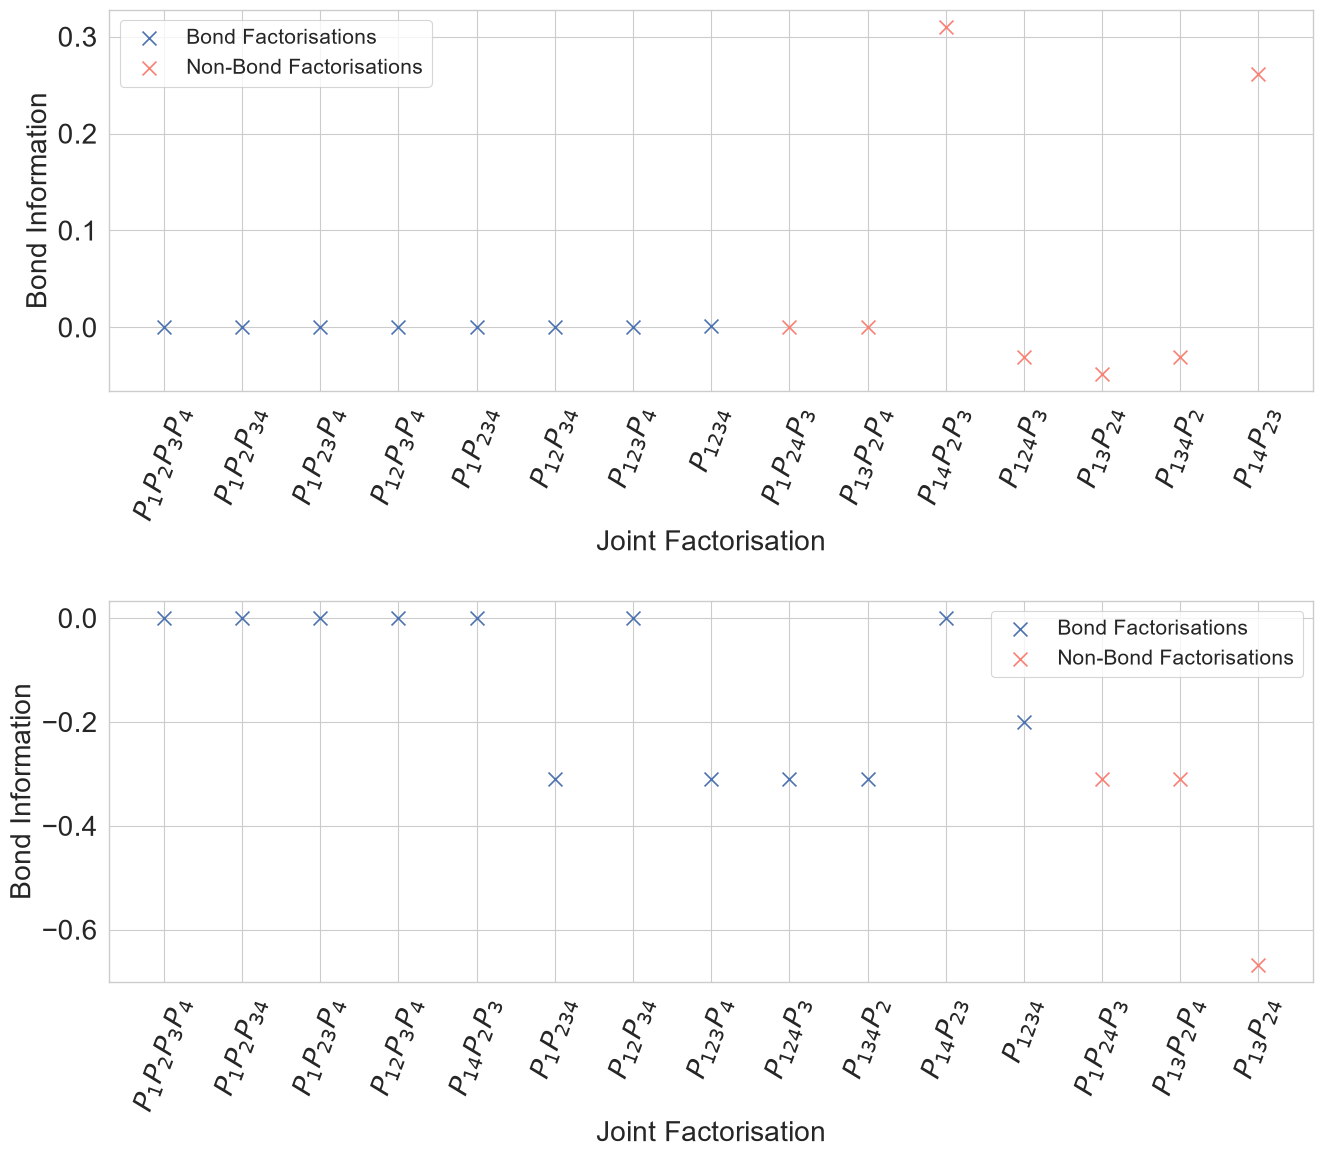

In [4]:
# Plotting
sns.set_theme(style="whitegrid", context="paper")

fig, (ax_path, ax_cycle) = plt.subplots(2, 1, figsize=(14, 12))

def plot_bi(ax, bond_facts, nonbond_facts):
    n_bond = len(bond_facts)
    n_total = n_bond + len(nonbond_facts)
    x = range(n_total)
    ax.scatter(x[:n_bond], list(bond_facts.values()), marker="x", s=100,
               label="Bond Factorisations")
    ax.scatter(x[n_bond:], list(nonbond_facts.values()), marker="x", s=100,
               color="salmon", label="Non-Bond Factorisations")
    ax.set_xticks(list(x))
    ax.set_xticklabels([bond_to_label(k) for k in bond_facts.keys()] +
                       [bond_to_label(k) for k in nonbond_facts.keys()], rotation=70)
    ax.set_ylabel("Bond Information", fontsize=20)
    ax.set_xlabel("Joint Factorisation", fontsize=20)
    ax.tick_params(labelsize=20)
    ax.legend(fontsize=15)

plot_bi(ax_path,  bond_facts_path,  nonbond_facts_path)
plot_bi(ax_cycle, bond_facts_cycle, nonbond_facts_cycle)

fig.subplots_adjust(left=0.12, right=0.98, top=0.96, bottom=0.15, hspace=0.55)
fig.savefig(r"C:\Users\morit\Thesis_Repo\Plots\bond_information_plots.pdf")